In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2
from scipy import stats

# Esercizio 1.1

Vogliamo ottenere i grafici che mostrano la media e la varianza in funzione dei lanci, con rispettivi errori in funzione dei blocchi.
Vengono generati $M = 100000$ numeri casuali uniformemente distribuiti nell'intervallo $[0,1)$ e divisi in $m = 100$ blocchi, ciascuno contenente $L = 1000$ eventi.

Per ogni blocco vengono calcolate:

- la media dei numeri casuali: $\langle x\rangle = \frac{1}{L}\sum_{j=1}^{L}x_j$

- la quantità: $\langle (x-0.5)^2\rangle$

Le medie dei blocchi vengono poi utilizzate per calcolare le medie progressive, cioè la media dei primi $i+1$ blocchi.

L'errore statistico viene stimato tramite:

$$
\sigma = \sqrt{\frac{\langle x^2\rangle-\langle x\rangle^2}{N}}
$$

Questa parte verifica quindi le proprietà della distribuzione uniforme tra 0 e 1.

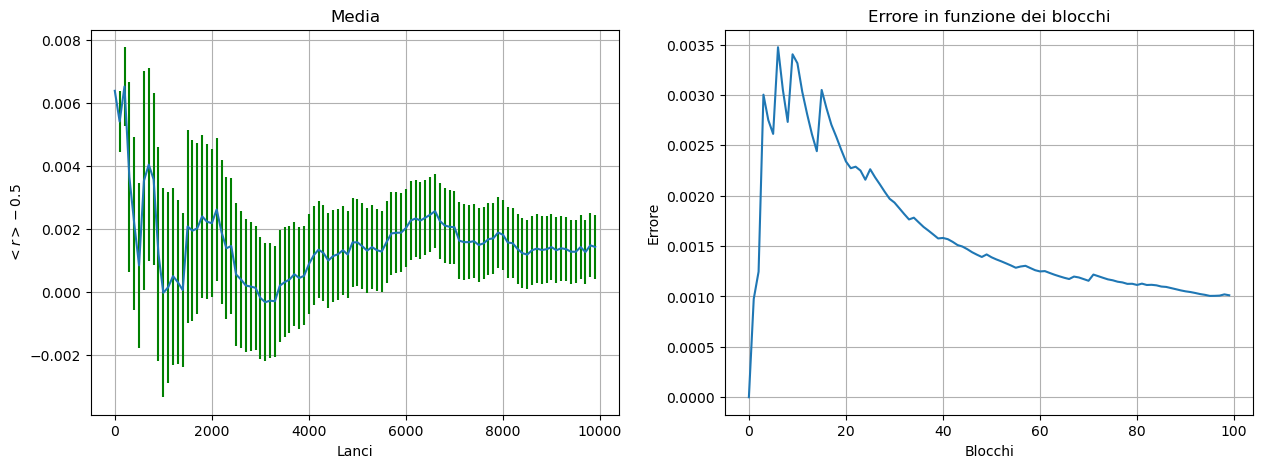

In [10]:
lanci=10000
blocchi=100
n=int(lanci/blocchi)

dat1 = np.loadtxt("sim_num_es01.1/Integrale.dat")
x = dat1[:, 0]
media = dat1[:, 1]
err = dat1[:, 2]

plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
x=(x*n)
plt.errorbar(x, media-0.5, yerr=err, ecolor='green')
plt.xlabel('Lanci')
plt.ylabel(r'$<r>-0.5$')
plt.title("Media")
plt.grid(True)

plt.subplot(1, 2, 2)

plt.plot(err)
plt.xlabel('Blocchi')
plt.ylabel('Errore')
plt.title("Errore in funzione dei blocchi")
plt.grid(True)
plt.show()

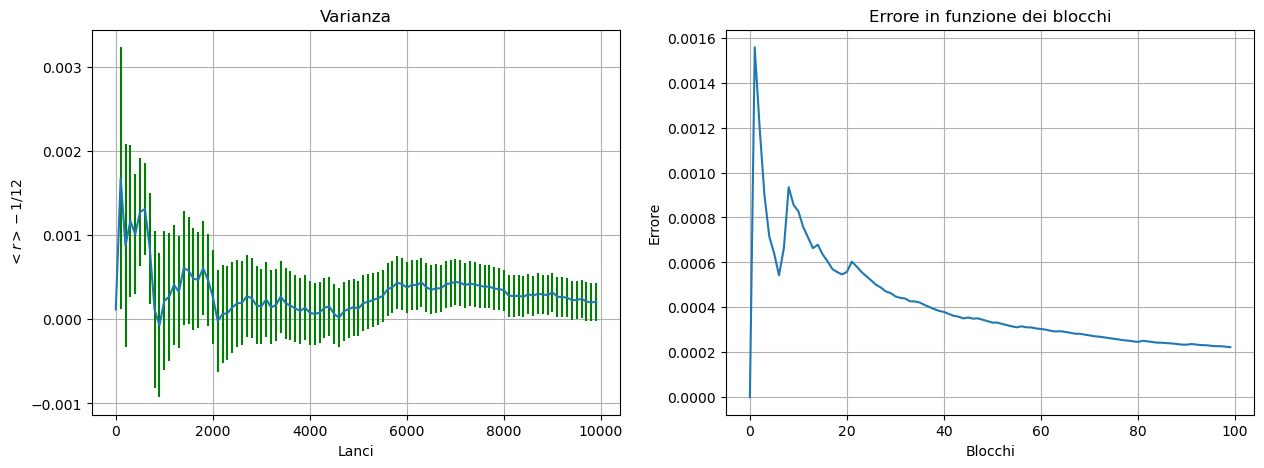

In [13]:
dat2 = np.loadtxt("sim_num_es01.1/Varianza.dat")
x = dat2[:, 0]
var = dat2[:, 1]
err2 = dat2[:, 2]

plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
x=(x*n)
plt.errorbar(x, var-1/12, yerr=err2, ecolor='green')
plt.xlabel('Lanci')
plt.ylabel(r'$<r>-1/12$')
plt.title("Varianza")
plt.grid(True)

plt.subplot(1, 2, 2)

plt.plot(err2)
plt.xlabel('Blocchi')
plt.ylabel('Errore')
plt.title("Errore in funzione dei blocchi")
plt.grid(True)
plt.show()

### Commento

Si osserva che, inizialmente, le stime presentano oscillazioni relativamente ampie e barre d’errore elevate. Questo è dovuto al numero ancora ridotto di blocchi e, quindi, alla limitata statistica disponibile. All’aumentare del numero di blocchi, le medie cumulative diventano progressivamente più stabili, mentre le barre d’errore diminuiscono secondo l’andamento atteso $1/\sqrt{N}$.

Infine, entrambe le stime convergono ai rispettivi valori teorici e risultano compatibili con essi entro l’errore statistico. Questo fornisce una verifica del corretto funzionamento del generatore pseudo-casuale e dell’efficacia del metodo del data blocking nella stima dell’incertezza statistica.


## Chi-Quadro

Per verificare se i numeri prodotti dal generatore sono effettivamente distribuiti secondo una distribuzione uniforme, si può effettuare un test del $\chi^2$ di Pearson, che fornisce una misura dello scostamento tra il numero di eventi osservati e quello atteso:

$$
\chi^2 = \sum_{i=1}^{M} \frac{(O_i-E_i)^2}{E_i}
$$

Si divide l'intervallo $[0,1]$ in $M=100$ sottointervalli di uguale ampiezza. Poiché la distribuzione è uniforme, la probabilità che un numero casuale cada in ciascun sottointervallo è $p=1/M=1/100$. Generando $n$ numeri pseudo-casuali, il numero atteso di eventi in ciascun bin è quindi $E_i=n/M$. Il $\chi^2$ di Pearson diventa:

$$
\chi^2 = \sum_{i=1}^{M} \frac{(n_i-n/M)^2}{n/M}.
$$

Poiché per una distribuzione uniforme ci si aspetta uno scostamento quadratico medio dell'ordine di $n/M$, il valore di $\chi^2$ atteso è dell'ordine di $M=100$. Tuttavia, il confronto con questo singolo valore non è sufficiente per stabilire la compatibilità con l'ipotesi di distribuzione uniforme.

Per una verifica più rigorosa, si ripete il test più volte e si confronta l'istogramma dei valori di $\chi^2$ ottenuti con la distribuzione teorica del $\chi^2$ con $M-1=99$ gradi di libertà.

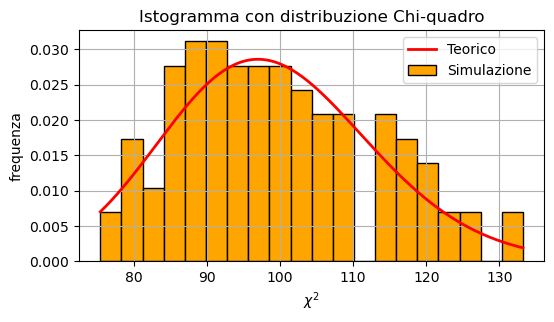

In [4]:
dati = np.loadtxt("sim_num_es01.1/chi.dat")
data = dati[:, 1]

media=np.mean(data)
stddev=np.std(data)

gdl=99

x=np.linspace(min(data), max(data), 500)
y=chi2.pdf(x, gdl)

plt.figure(figsize=(6, 3))
plt.plot(x, y, 'r-', lw=2, label='Teorico')
plt.hist(data, bins=20, density=True, color='orange', edgecolor='black', label="Simulazione")

plt.xlabel(r'$\chi^2$')
plt.ylabel('frequenza')
plt.title('Istogramma con distribuzione Chi-quadro')
plt.legend()
plt.grid()
plt.show()

### Commento
Si osserva che il valore medio della distribuzione simulata risulta compatibile con quello atteso, e i dati si dispongono in modo equilibrato attorno a tale valore. Non emergono scostamenti sistematici rispetto alla curva teorica: l’istogramma segue correttamente l’andamento previsto su tutto il dominio, incluse le regioni di coda. Nel complesso, non si osservano deviazioni statisticamente significative che possano suggerire un rigetto dell’ipotesi di uniformità dei numeri pseudo‑casuali utilizzati.

# Esercizio 1.2

Nell'esercizio si studia il Teorema del Limite Centrale generando numeri casuali secondo tre diverse distribuzioni:

-distribuzione uniforme $U(0,1)$;

-distribuzione esponenziale con parametro $\lambda=1$;

-distribuzione di Cauchy-Lorentz con $\mu=0$ e $\Gamma=1$.

Per ciascuna distribuzione vengono generati $N=10000$ valori mediando rispettivamente $N=1,2,10,100$ estrazioni indipendenti. In particolare, per ogni valore di $N$ vengono calcolate le quantità
$$
\bar{x}N=\frac{1}{N}\sum{i=1}^{N}x_i.
$$

L'obiettivo è osservare come varia la distribuzione delle medie al variare di $N$. Secondo il Teorema del Limite Centrale, per $N$ sufficientemente grande, la distribuzione delle medie tende a una distribuzione gaussiana, indipendentemente dalla distribuzione di partenza, purché questa abbia media e varianza finite.

Nel caso della distribuzione di Cauchy-Lorentz, tuttavia, il teorema non è applicabile perché la sua varianza non è finita. Per questo motivo, anche aumentando $N$, la distribuzione delle medie non converge a una gaussiana., ma rimane un Cauchy-Lorentz.

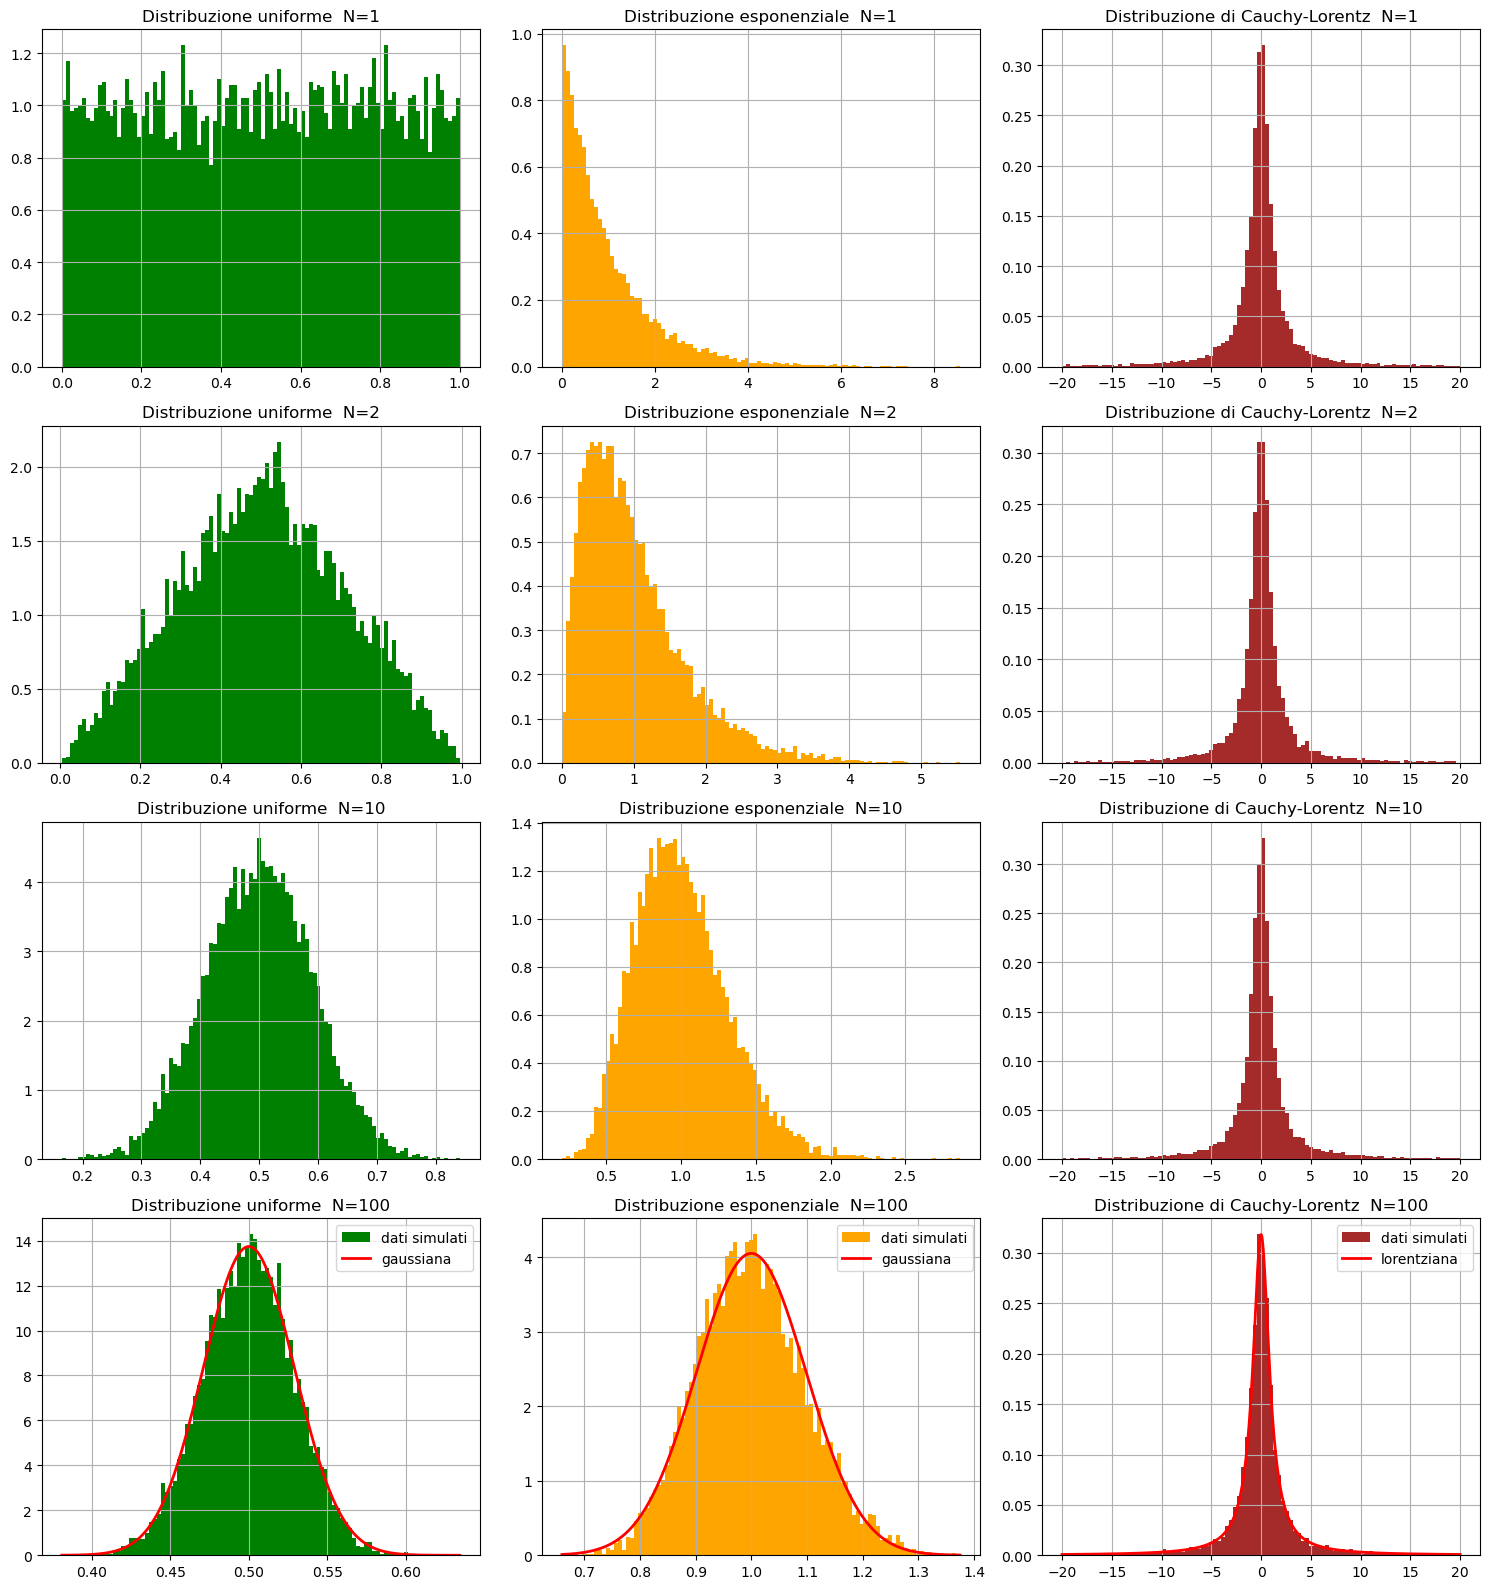

In [12]:
N = [1, 2, 10, 100]
unif, exp, lorentz = [], [], []

for n in N:
    dati = np.loadtxt(f"sim_num_es01.2/dati{n}.dat")
    unif.append(dati[:, 0])
    exp.append(dati[:, 1])
    lorentz.append(dati[:, 2])
    
fig, ax = plt.subplots(4, 3, figsize=(15, 16))

col_colors = ["green", "orange", "brown"]
col_titles = ["Uniforme", "Esponenziale", "Lorentziana"]

for i, n in enumerate(N):
    # Uniforme
    ax[i, 0].hist(unif[i], density=True, bins=100, color="green", label="dati simulati")
    ax[i, 0].set_title(f"Distribuzione uniforme  N={n}")
    ax[i, 0].grid(True)

    # Esponenziale
    ax[i, 1].hist(exp[i], density=True, bins=100, color="orange", label="dati simulati")
    ax[i, 1].set_title(f"Distribuzione esponenziale  N={n}")
    ax[i, 1].grid(True)

    # Lorentziana
    ax[i, 2].hist(lorentz[i], range=(-20, 20), bins=100, density=True, color="brown", label="dati simulati")
    ax[i, 2].set_title(f"Distribuzione di Cauchy-Lorentz  N={n}")
    ax[i, 2].grid(True)
    
# Curve teoriche

#Gaussiana uniforme
m, s = unif[3].mean(), unif[3].std()
x = np.linspace(unif[3].min(), unif[3].max(), 1000)
ax[3, 0].plot(x, stats.norm.pdf(x, loc=m, scale=s), color="red", lw=2, label="gaussiana")
ax[3, 0].legend()

# Gaussiana esponenziale
m, s = exp[3].mean(), exp[3].std()
x = np.linspace(exp[3].min(), exp[3].max(), 1000)
ax[3, 1].plot(x, stats.norm.pdf(x, loc=m, scale=s), color="red", lw=2, label="gaussiana")
ax[3, 1].legend()

# Lorentziana
x = np.linspace(-20, 20, 1000)
ax[3, 2].plot(x, stats.cauchy.pdf(x, loc=0, scale=1), color="red", lw=2, label="lorentziana")
ax[3, 2].legend()

plt.tight_layout()
plt.show()

### Commento

Si osserva che la distribuzione uniforme ed esponenziale convergono a una Gaussiana. Ciò è evidente già da $N=10$, ma il confronto con la curva teorica è ottimo a $N=100$.

La distribuzione di Cauchy-Lorentz si comporta in modo diverso: la forma degli istogrammi rimane Lorentziana per qualunque $N$. Vedo la sovrapposizione con la curva teorica per $N=100$, il che conferma che $S_N$ ha la stessa distribuzione del singolo campione.

# Esercizio 1.3


Quando si lancia casualmente un ago di lunghezza $L$ su un piano attraversato da righe parallele distanti $d$, la probabilità che l'ago intersechi una delle righe è

$$
P=\frac{2L}{\pi d}.
$$

Invertendo questa relazione e considerando $N_{thr}$ lanci, di cui $N_{hit}$ intersecano una riga, si ottiene una stima di $\pi$:

$$
\pi=\frac{2L}{Pd}
\simeq
\frac{2LN_{thr}}{N_{hit}d}.
$$

Nella simulazione sono stati effettuati $M=10^4$ lanci, suddivisi in $100$ blocchi, utilizzando $d=0.7$ e $L=1$.

Per generare casualmente l'angolo dell'ago senza utilizzare direttamente il valore di $\pi$, si utilizza il metodo del rigetto. Vengono estratte due coordinate casuali $x$ e $y$ uniformemente nell'intervallo $[0,1]$ e si considerano solo le coppie che soddisfano

$$
x^2+y^2\leq1.
$$

In questo modo si ottiene un punto casuale nel primo quadrante del cerchio unitario. L'angolo corrispondente può essere quindi calcolato come

$$
\theta=\arctan\left(\frac{y}{x}\right),
$$

ottenendo così un angolo distribuito uniformemente in $[0,\pi/2]$, senza dover utilizzare esplicitamente $\pi$ nella generazione.


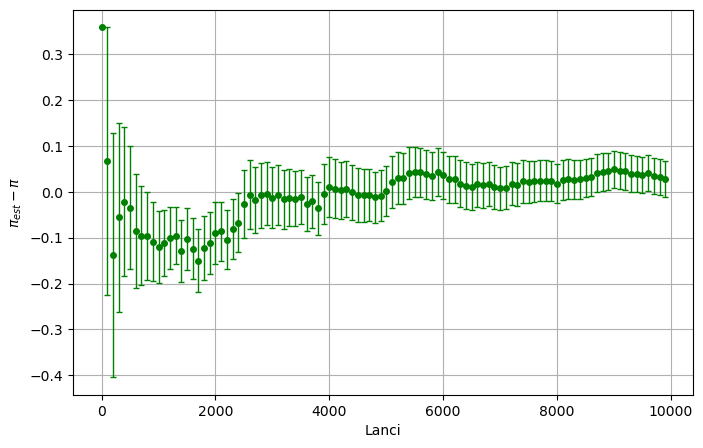

Stima finale di π: 3.16876 +/- 0.0387569


In [2]:
pi_values = np.loadtxt("sim_num_es01.3/Buffon.dat")
mean_pi = pi_values[:,1]
delta_mean = mean_pi - np.pi
error_pi = pi_values[:,2]
x = pi_values[:, 0] * 100


plt.figure(figsize=(8,5))
plt.errorbar(x, delta_mean, yerr=error_pi, fmt='o', color='green', elinewidth=1, capsize=2, markersize=4)
plt.xlabel("Lanci")
plt.ylabel(r"$\pi_{est} - \pi$")
plt.grid(True)
plt.show()

print("Stima finale di π:", mean_pi[-1], "+/-", error_pi[-1])

La stima finale di π  converge al valore reale entro le barre di incertezza statistica al crescere del numero di lanci.